In [16]:
import math
import os
import pandas as pd
from datetime import datetime
from onekey_algo import get_param_in_cwd

label_data = pd.read_csv(get_param_in_cwd('label_file'))[['ID', 'group']]
label_data['ID'] = label_data['ID'].map(lambda x: os.path.splitext(x)[0])
display(label_data['group'].value_counts())
label_data

train    177
val       77
test      51
Name: group, dtype: int64

,ID,group
0,陈博201803-202302,train
1,齐明旭201609-201802,train
2,姜心忠202202-202403,train
3,司振哲201906-202302,train
4,胡轩铖202208-202407,train
...,...,...
300,张颖泰20230525-20241024,test
301,赵恩笛20230915-20250105,test
302,赵鹏20200521-20241107,test
303,赵志男20230401-20241112,test


In [18]:
import math
import os
import pandas as pd
from datetime import datetime
from onekey_algo import get_param_in_cwd
from onekey_algo.custom.utils import print_join_info
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, mean_absolute_error


def remove_outliers_percentile(df, column, lower_percentile=1, upper_percentile=99):
    lower_limit = df[column].quantile(lower_percentile/100)
    upper_limit = df[column].quantile(upper_percentile/100)
    
    return df[(df[column] >= lower_limit) & (df[column] <= upper_limit)]

def get_log(log_path, map2gz:bool = True):
    log_ = pd.read_csv(log_path, names=['fname', 'Prediction', 'Ground Truth'], sep='\t')
    if map2gz:
        log_['ID'] = log_['fname'].map(lambda x: os.path.basename(x).replace('.npy', ''))
    else:
        log_['ID'] = log_['fname'].map(lambda x: os.path.basename(x))
    return log_

epoch_mapping = {'resnet50': {'DL3D': 20, 'DL2D': 50,},
                 'vgg19': {'2.5D': 7, 'DL2D': 33, },
                 'resnet18': {'2.5D': 7, 'DL2D': 11, },
                 'resnet101': {'2.5D': 17, 'DL2D': 31, },
                 'densenet121': {'2.5D': 10, 'DL2D': 53, },
                 'inception_v3': {'2.5D': 10, 'DL2D': 85, },
                 'CrossFormer': {'2.5D': 17, 'DL2D': 193, },
                 'TwinsSVT': {'2.5D': 17, 'DL2D': 56,},
                 'SimpleViT': {'2.5D': 10, 'DL2D': 5,},
                 'ResNet50': {'DL3D': 20, },
                 'ShuffleNet': {'DL3D': 22,},
                 'ResNet101': {'3D': 35},
                 'DenseNet121': {'DL3D': 33, }}
os.makedirs('results', exist_ok=True)
models = ['vgg19', 'resnet50', 'densenet121',  ]
metrics = []
logs = []
for modal in get_param_in_cwd('modals1', ['DL2D']):
    minv = 1e10
    for epoch_ in range(63, 64):
        for cv in range(0, 1):
            model_root = os.path.join(get_param_in_cwd('radio_dir'), 'Lmodels', f'CV-{cv}')
            for idx_, model in enumerate(models):
#             for model in os.listdir(model_root):
                if model != 'vgg19' and False:
                    continue
                all_pred = []
                all_gt = []
                all_groups = []
#                 val_log = pd.concat([get_log(os.path.join(model_root, model, f"viz/BST_TRAIN_RESULTS.txt")),
#                                     get_log(os.path.join(model_root, model, f"viz/BST_VAL_RESULTS.txt"))], axis=0)
#                 val_log = pd.concat([get_log(os.path.join(model_root, model, f"train/Epoch-{epoch_}.txt")),
#                                     get_log(os.path.join(model_root, model, f"valid/Epoch-{epoch_}.txt"))], axis=0)
                val_log = pd.concat([get_log(os.path.join(model_root, model, f"train/Epoch-{epoch_mapping[model][modal]}.txt")),
                                    get_log(os.path.join(model_root, model, f"valid/Epoch-{epoch_mapping[model][modal]}.txt"))], axis=0)
#                 display(val_log)
#                 print_join_info(val_log, label_data)
                val_log = pd.merge(val_log, label_data, on='ID', how='inner')
                val_log.to_csv(f'results/{modal}_{model}.csv', index=False, encoding='utf-8-sig')
                display(val_log.shape)
#                 for c in ['Prediction', 'Ground Truth']:
#                     val_log[c] = val_log[c].map(lambda x: map2e(x))
#                 display(val_log)
                # 去除头部和尾部1%的极端值
                val_log['model'] = model
                logs.append(val_log)
                for subset in get_param_in_cwd('subsets'):
                    log = val_log[val_log['group'] == subset]
                    log[['ID', 'Prediction']].to_csv(f'results/{modal}_{model}_{subset}.csv', index=False, encoding='utf-8-sig')
                    log = remove_outliers_percentile(log, 'Ground Truth', lower_percentile=5, upper_percentile=95)
                    mse = mean_squared_error(log['Ground Truth'], log['Prediction'])
                    mape = mean_absolute_error(log['Ground Truth'], log['Prediction'])
                    metrics.append([model, mse, mape, subset])
                    if minv > mse and subset == 'val':
                        print(model, epoch_, subset, f"MSE:{mse}, MAPE:{mape}", log.shape, '--------------')
                        minv = mse
                    else:
                        print(model, epoch_, subset, f"MSE:{mse}, MAPE:{mape}", log.shape)
metric = pd.DataFrame(metrics, columns=['model_name', 'MSE', 'MAPE', 'Cohort'])
metric.to_csv(f'results/{modal}_regression.csv', index=False)
metric

(288, 5)

vgg19 63 train MSE:0.7216085211551124, MAPE:0.7840602000000001 (160, 6)
vgg19 63 val MSE:0.5928399439258657, MAPE:0.7121356865671641 (67, 6) --------------
vgg19 63 test MSE:0.5050822308006808, MAPE:0.662117744680851 (47, 6)


(288, 5)

resnet50 63 train MSE:0.7089259773926125, MAPE:0.7844208625 (160, 6)
resnet50 63 val MSE:0.5954159342542239, MAPE:0.6989118059701492 (67, 6)
resnet50 63 test MSE:0.6198087145028085, MAPE:0.726309234042553 (47, 6)


(288, 5)

densenet121 63 train MSE:0.7788885983926125, MAPE:0.8033206249999999 (160, 6)
densenet121 63 val MSE:0.6630548285228806, MAPE:0.7415386716417909 (67, 6)
densenet121 63 test MSE:0.5522310893964255, MAPE:0.6776346382978724 (47, 6)


,model_name,MSE,MAPE,Cohort
0,vgg19,0.722,0.784,train
1,vgg19,0.593,0.712,val
2,vgg19,0.505,0.662,test
3,resnet50,0.709,0.784,train
4,resnet50,0.595,0.699,val
5,resnet50,0.620,0.726,test
6,densenet121,0.779,0.803,train
7,densenet121,0.663,0.742,val
8,densenet121,0.552,0.678,test


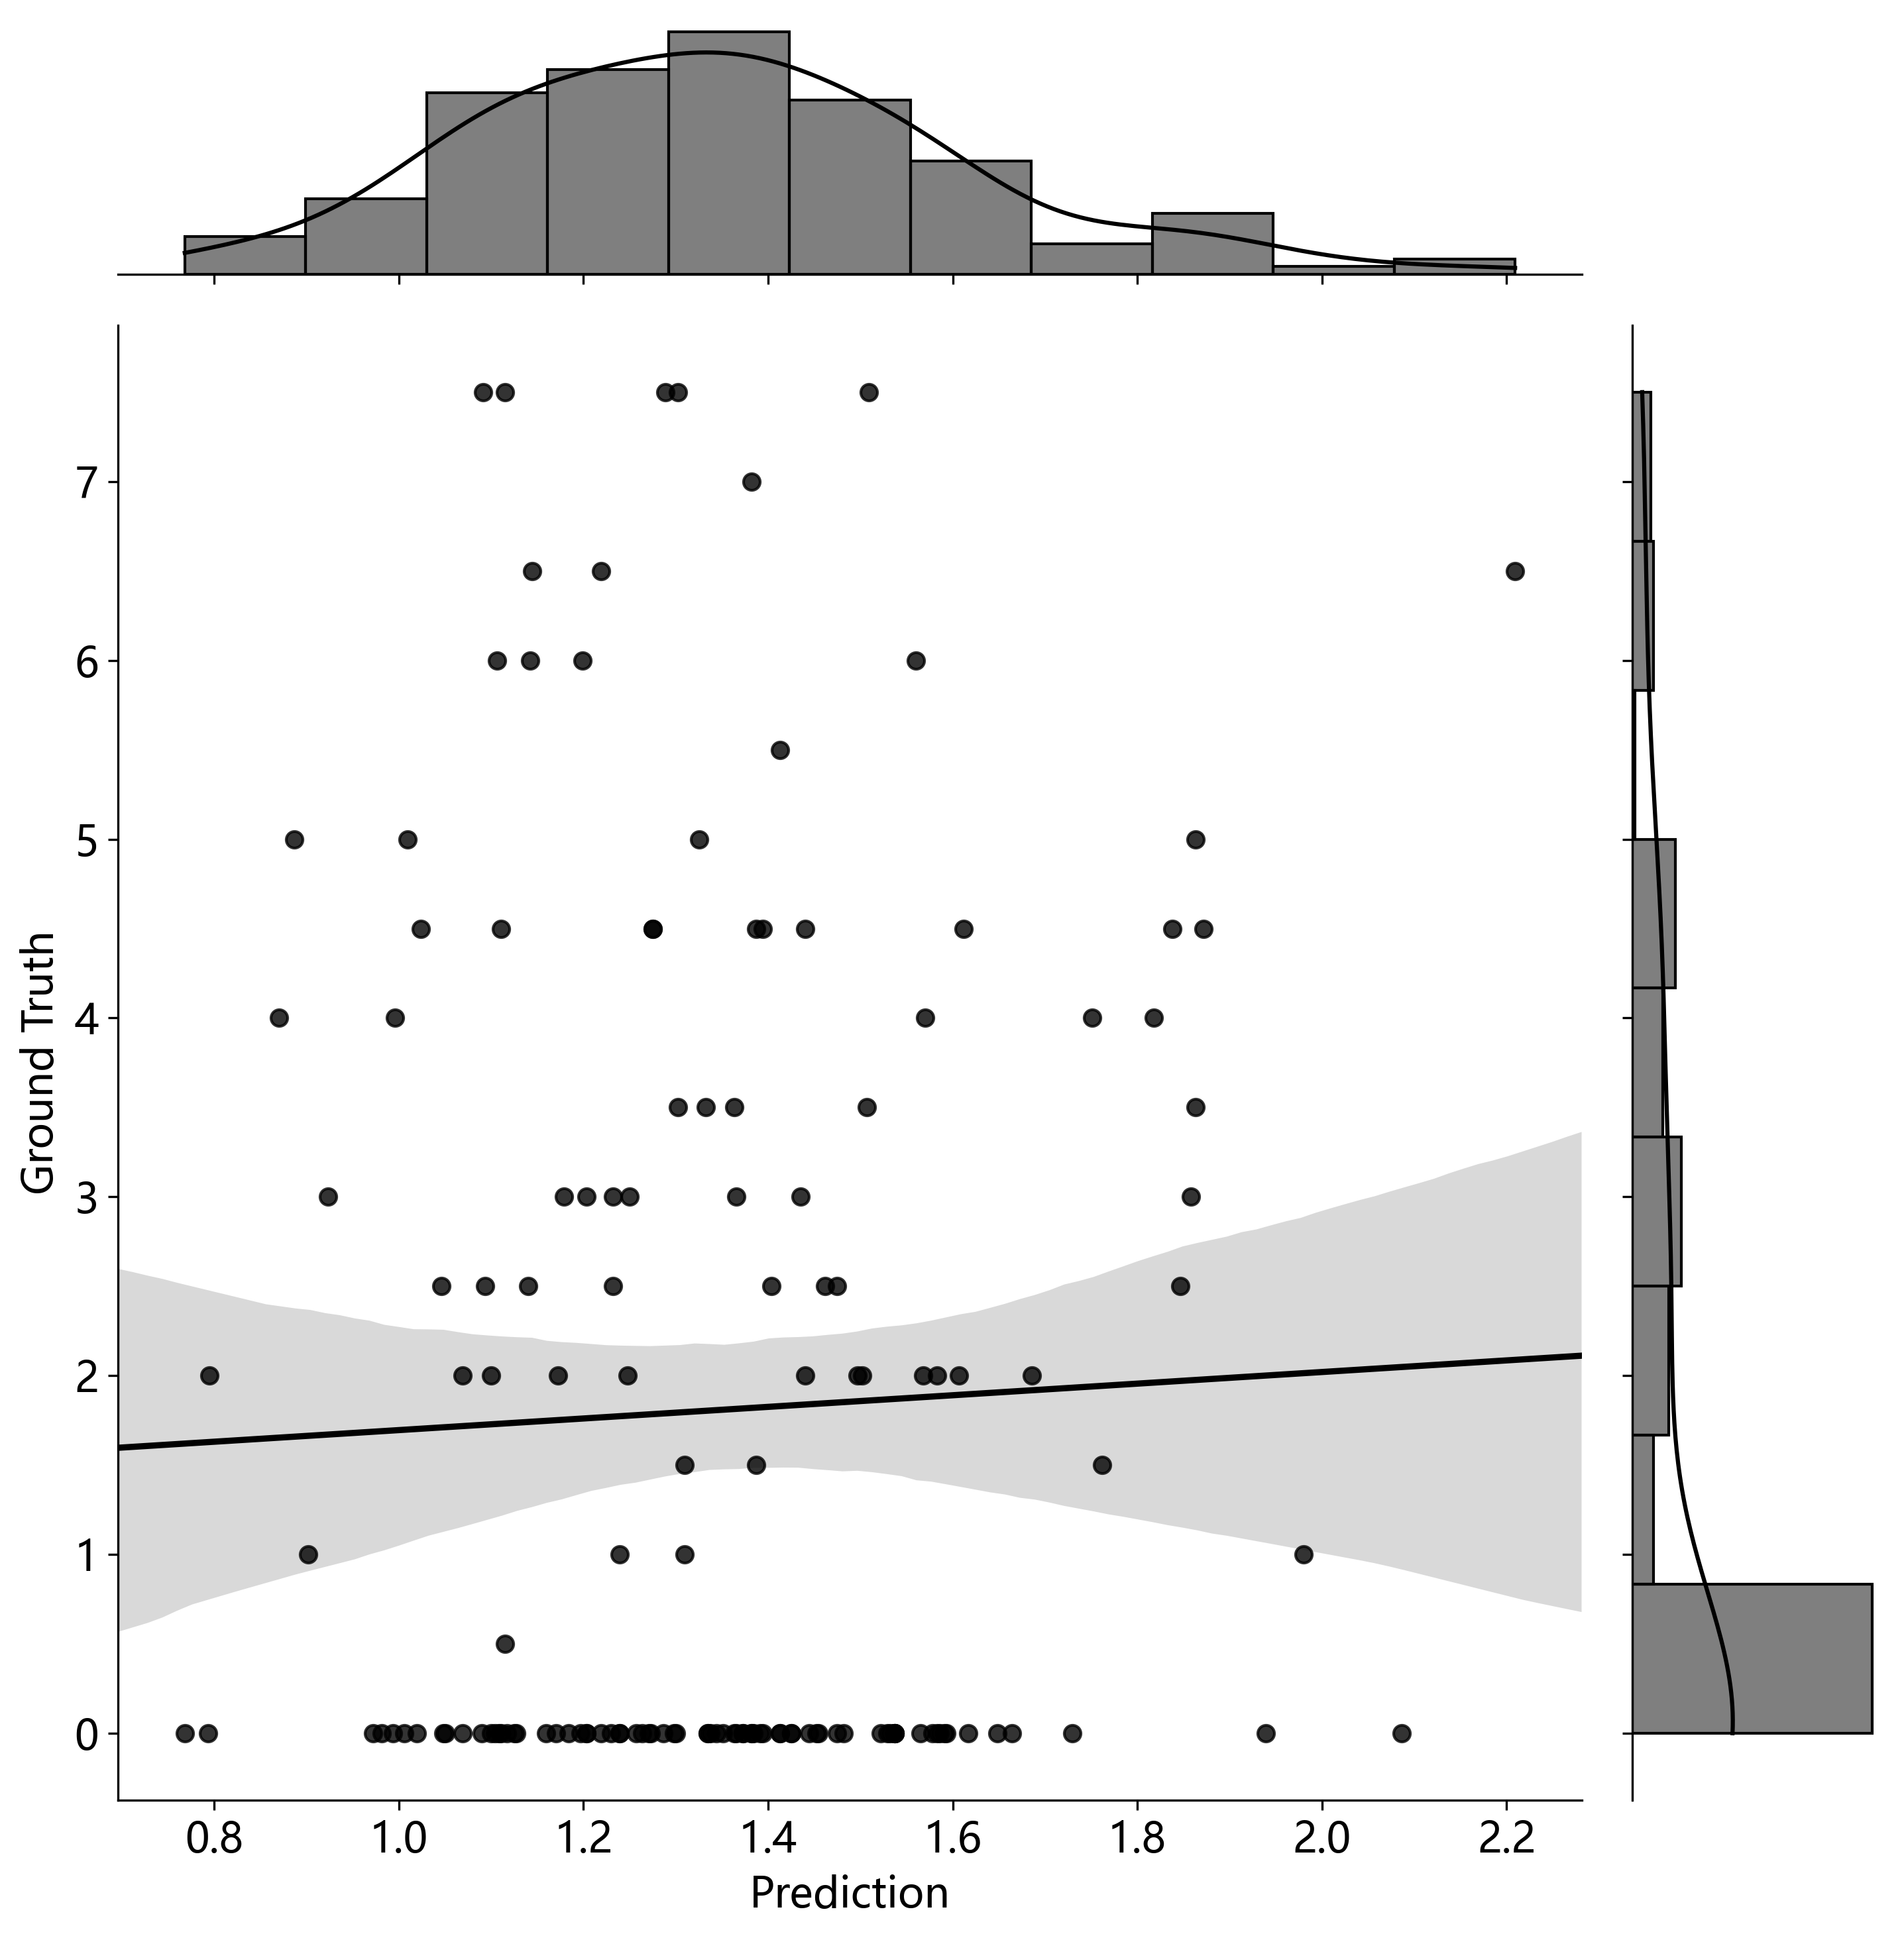

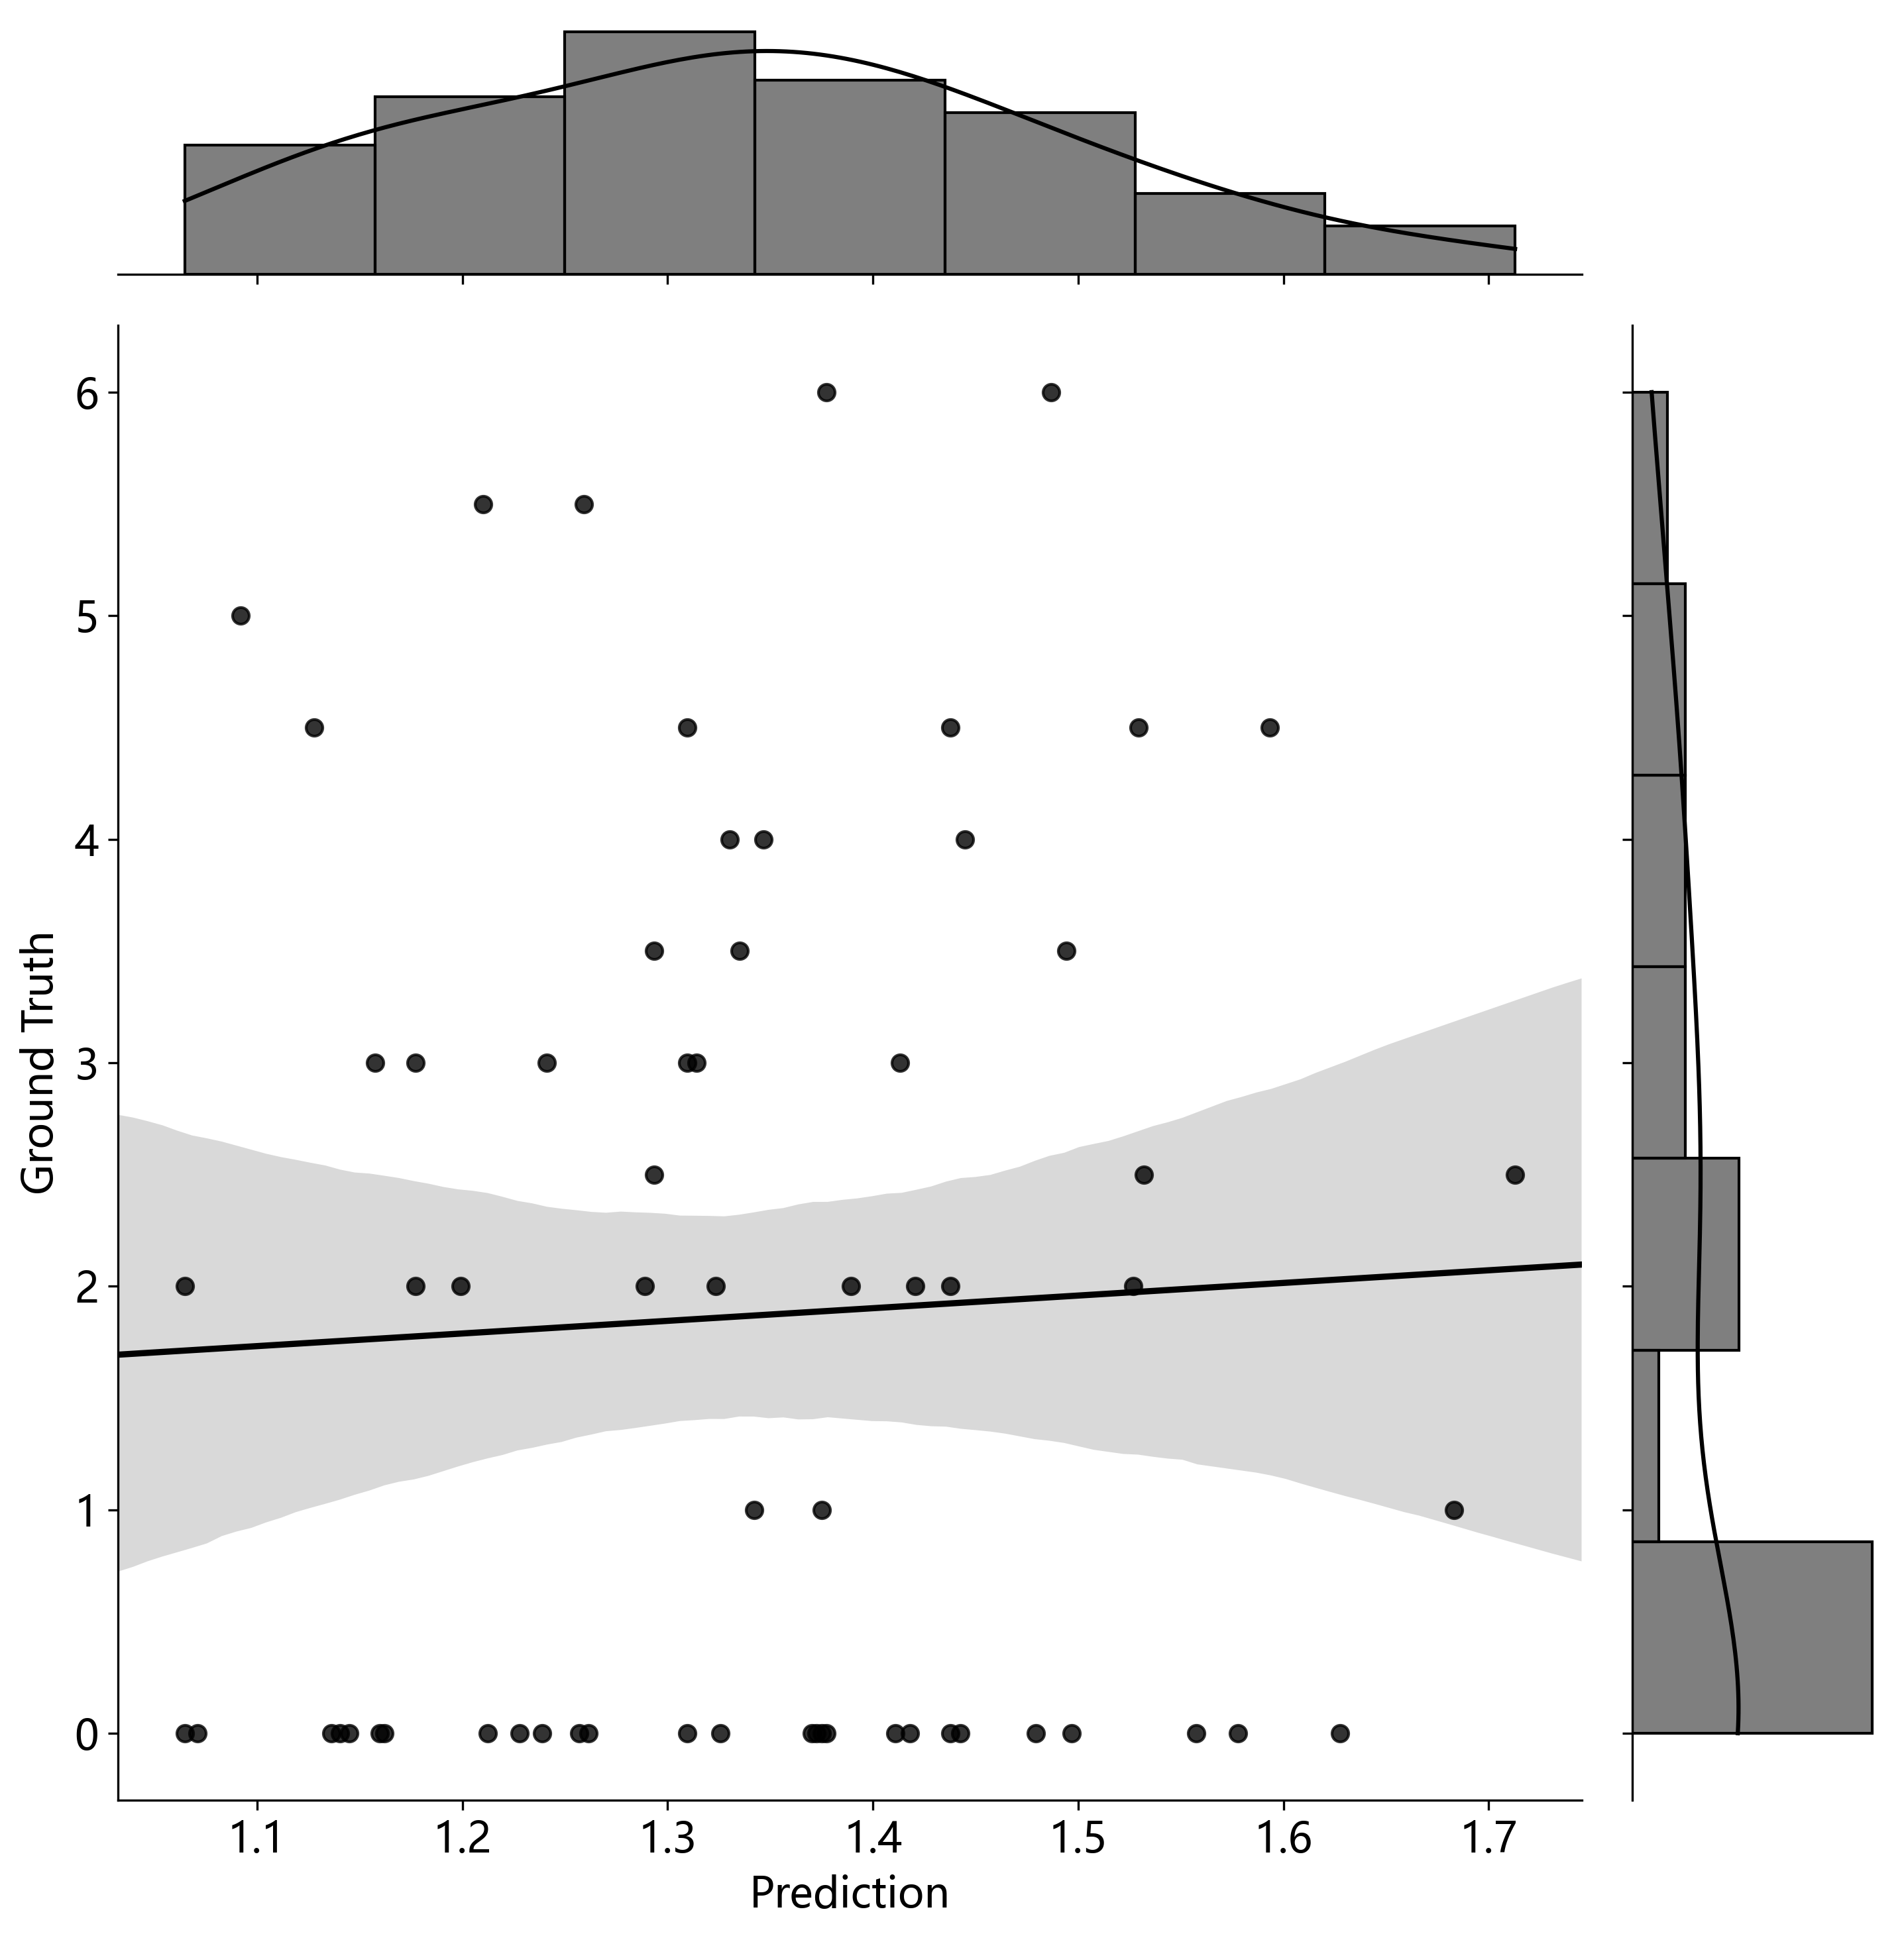

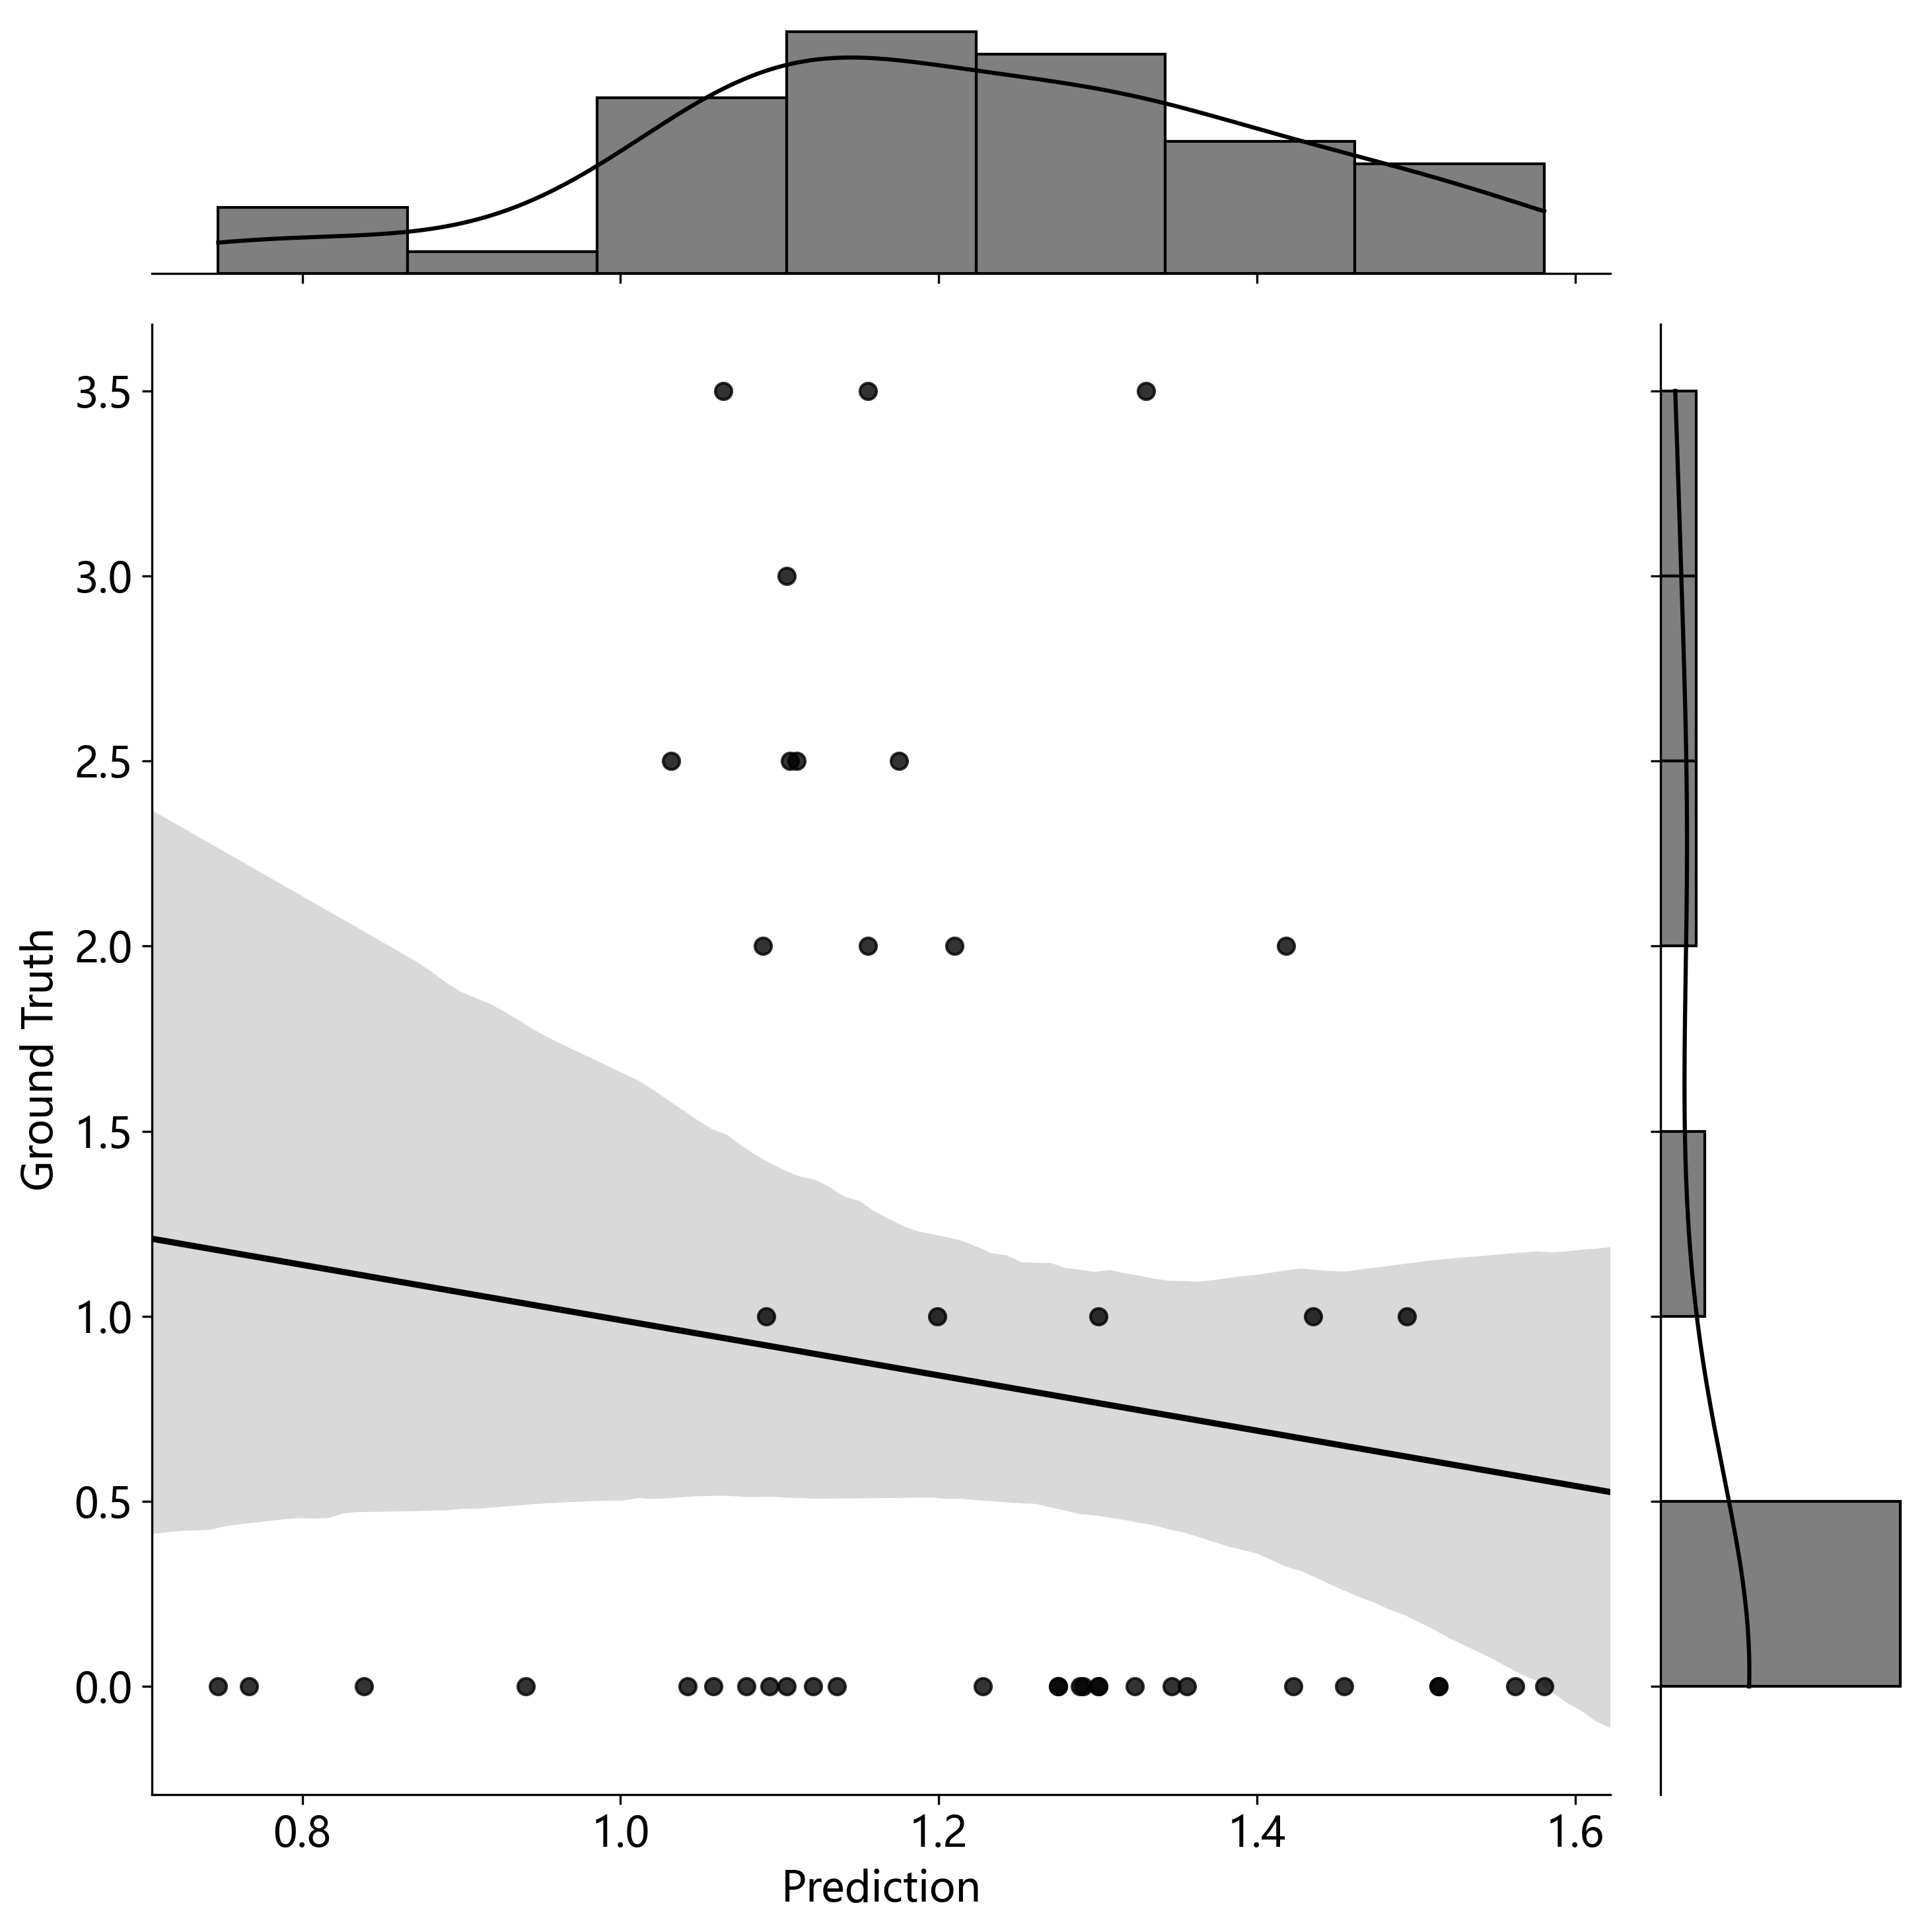

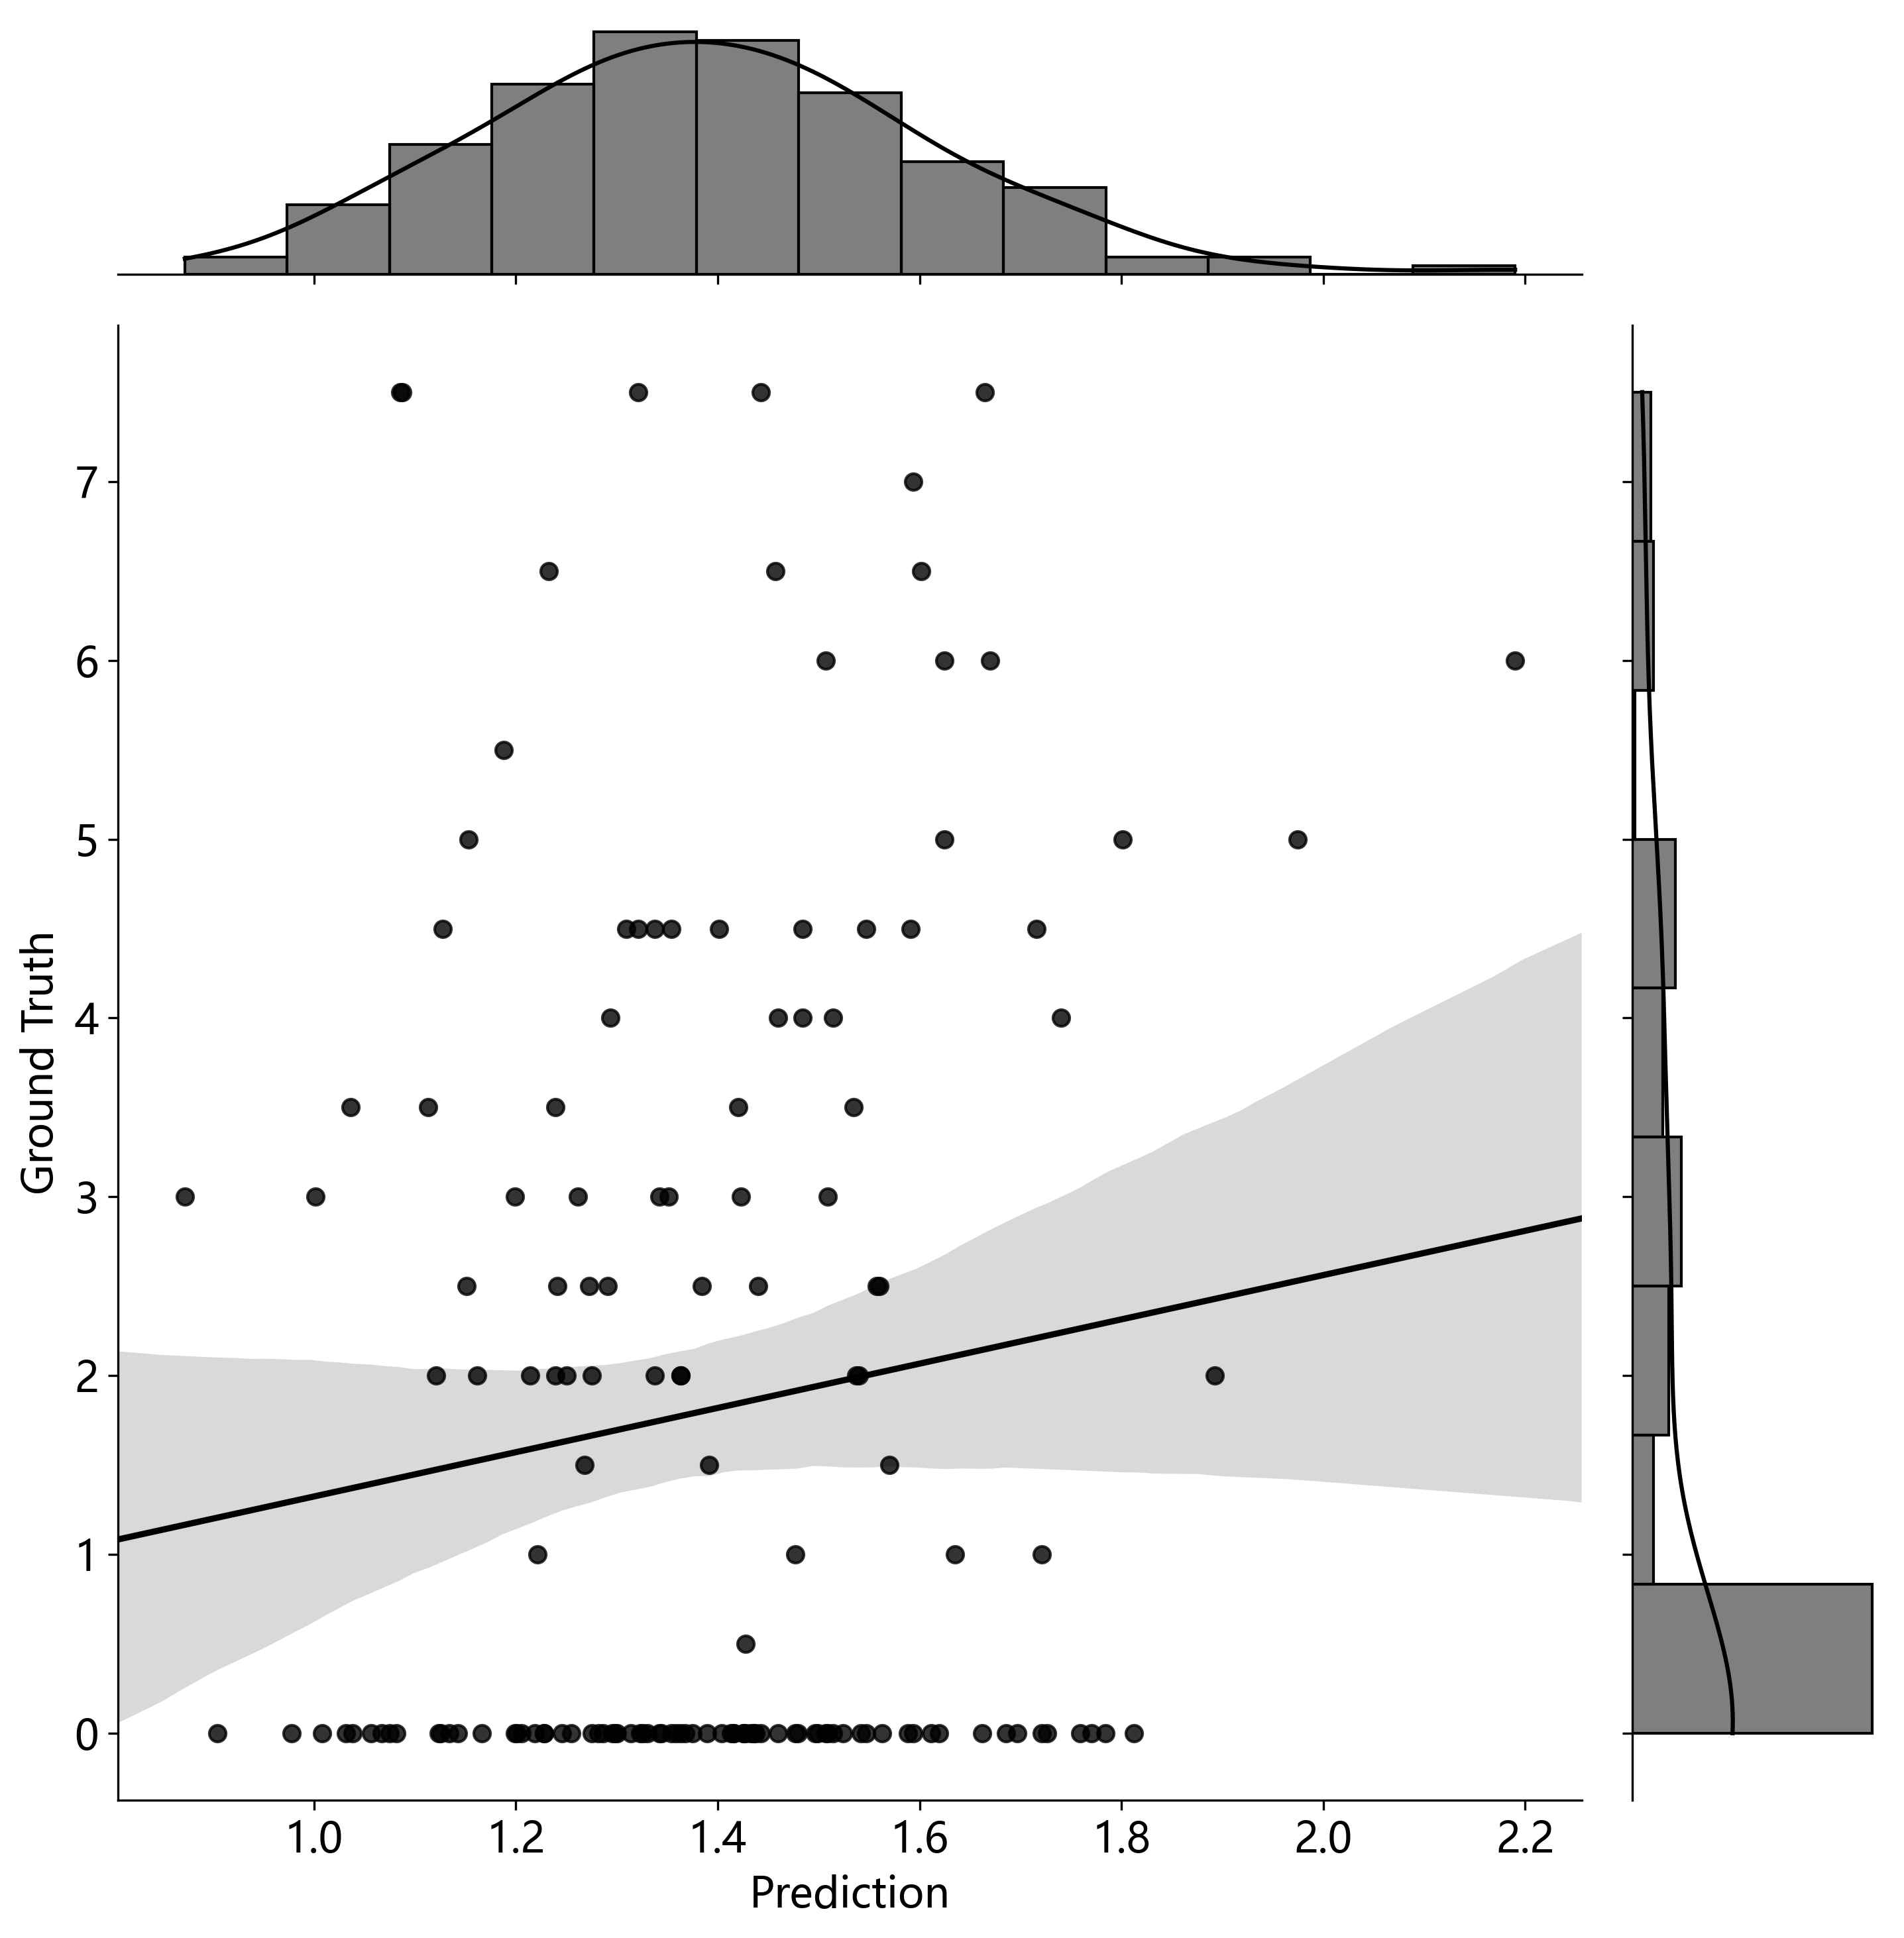

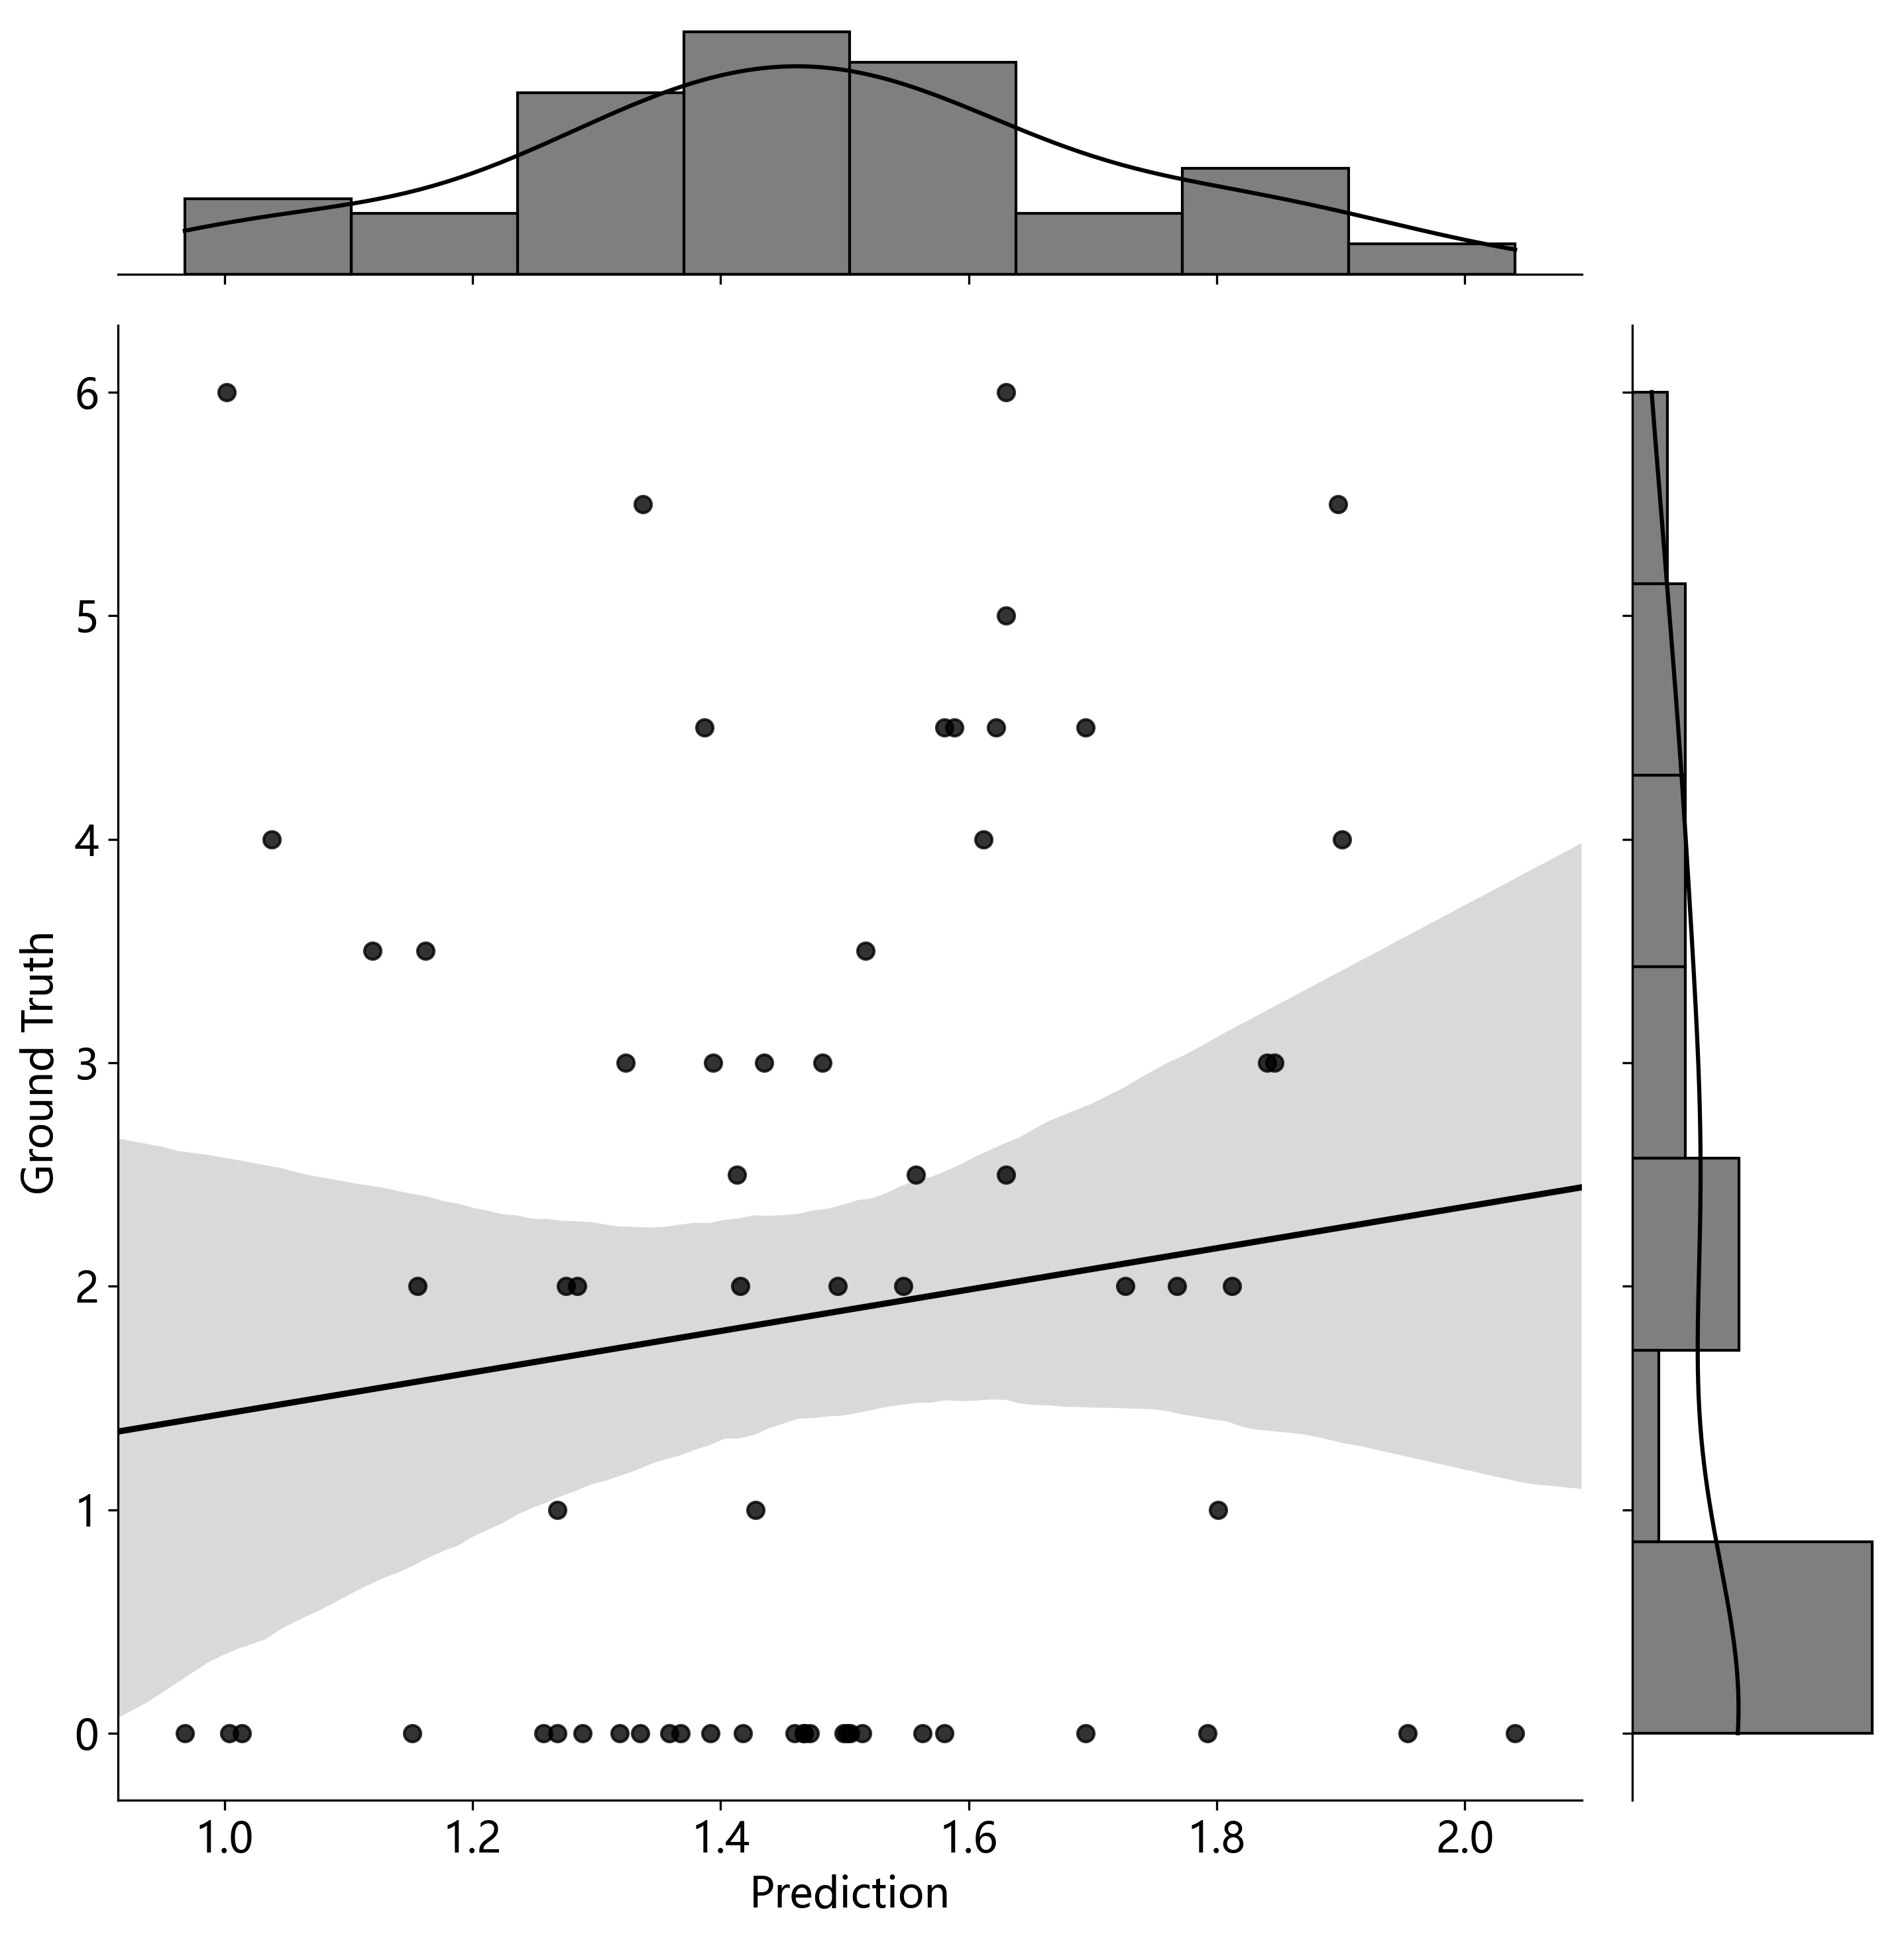

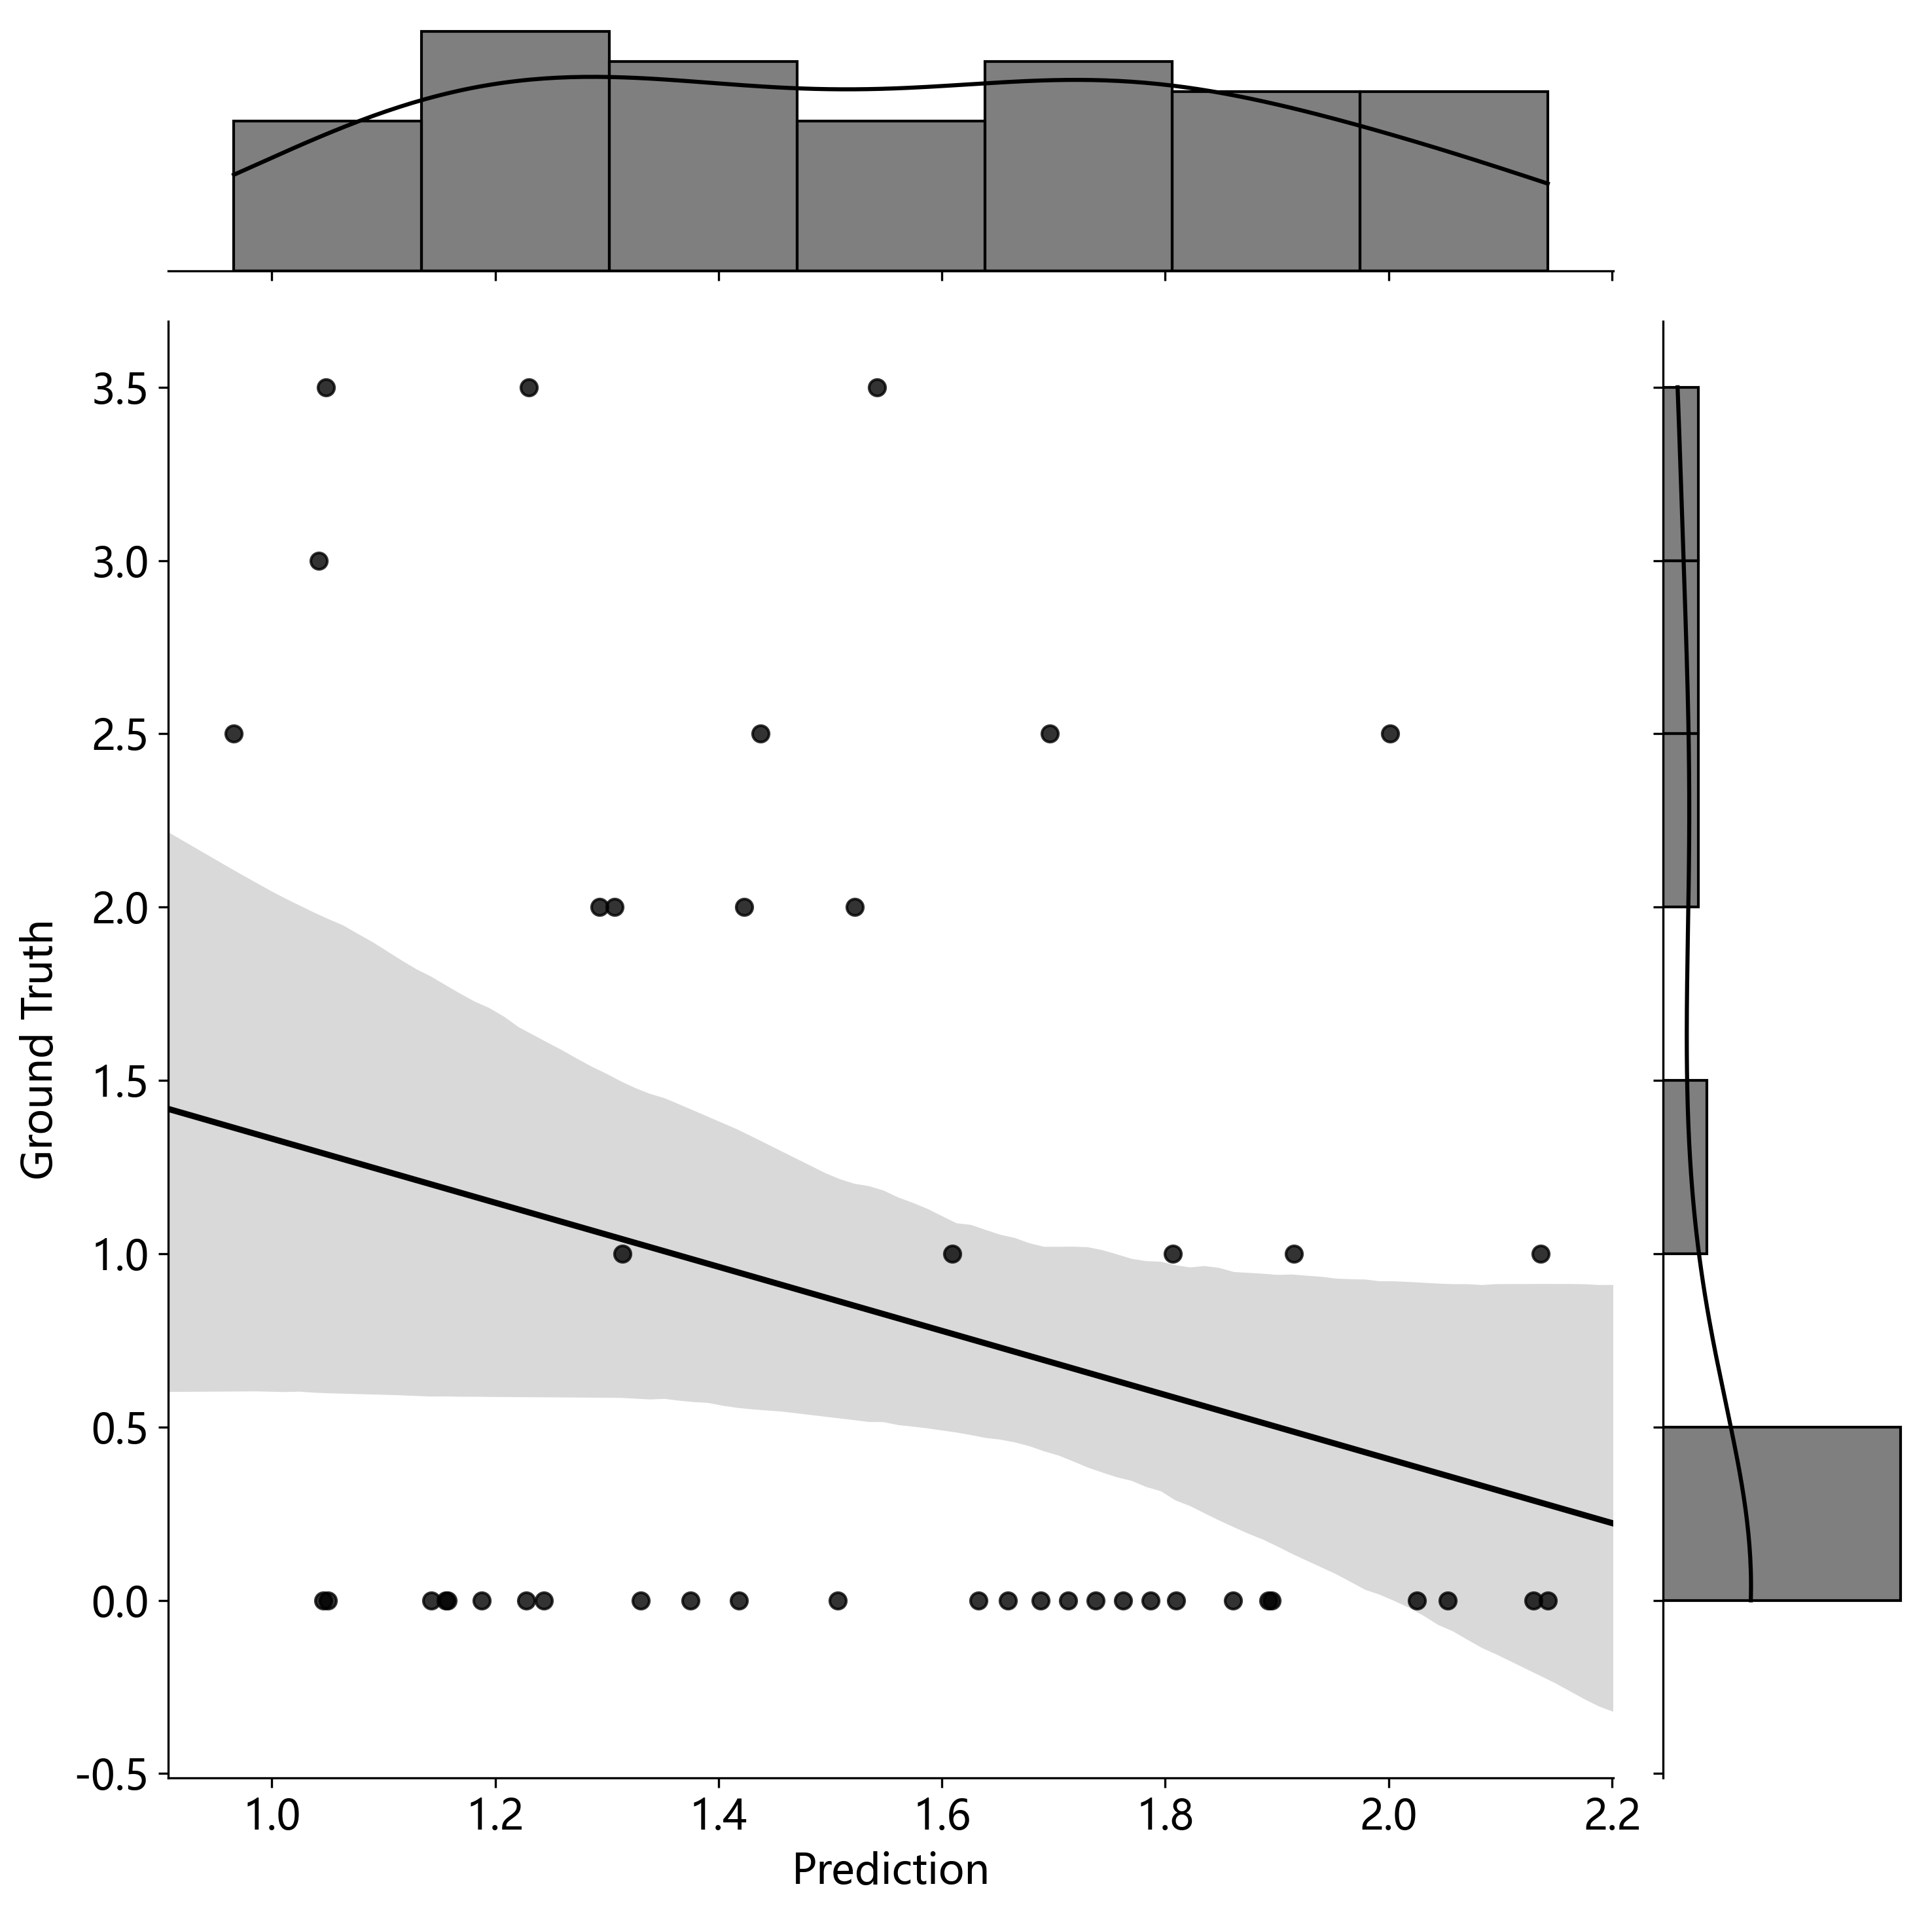

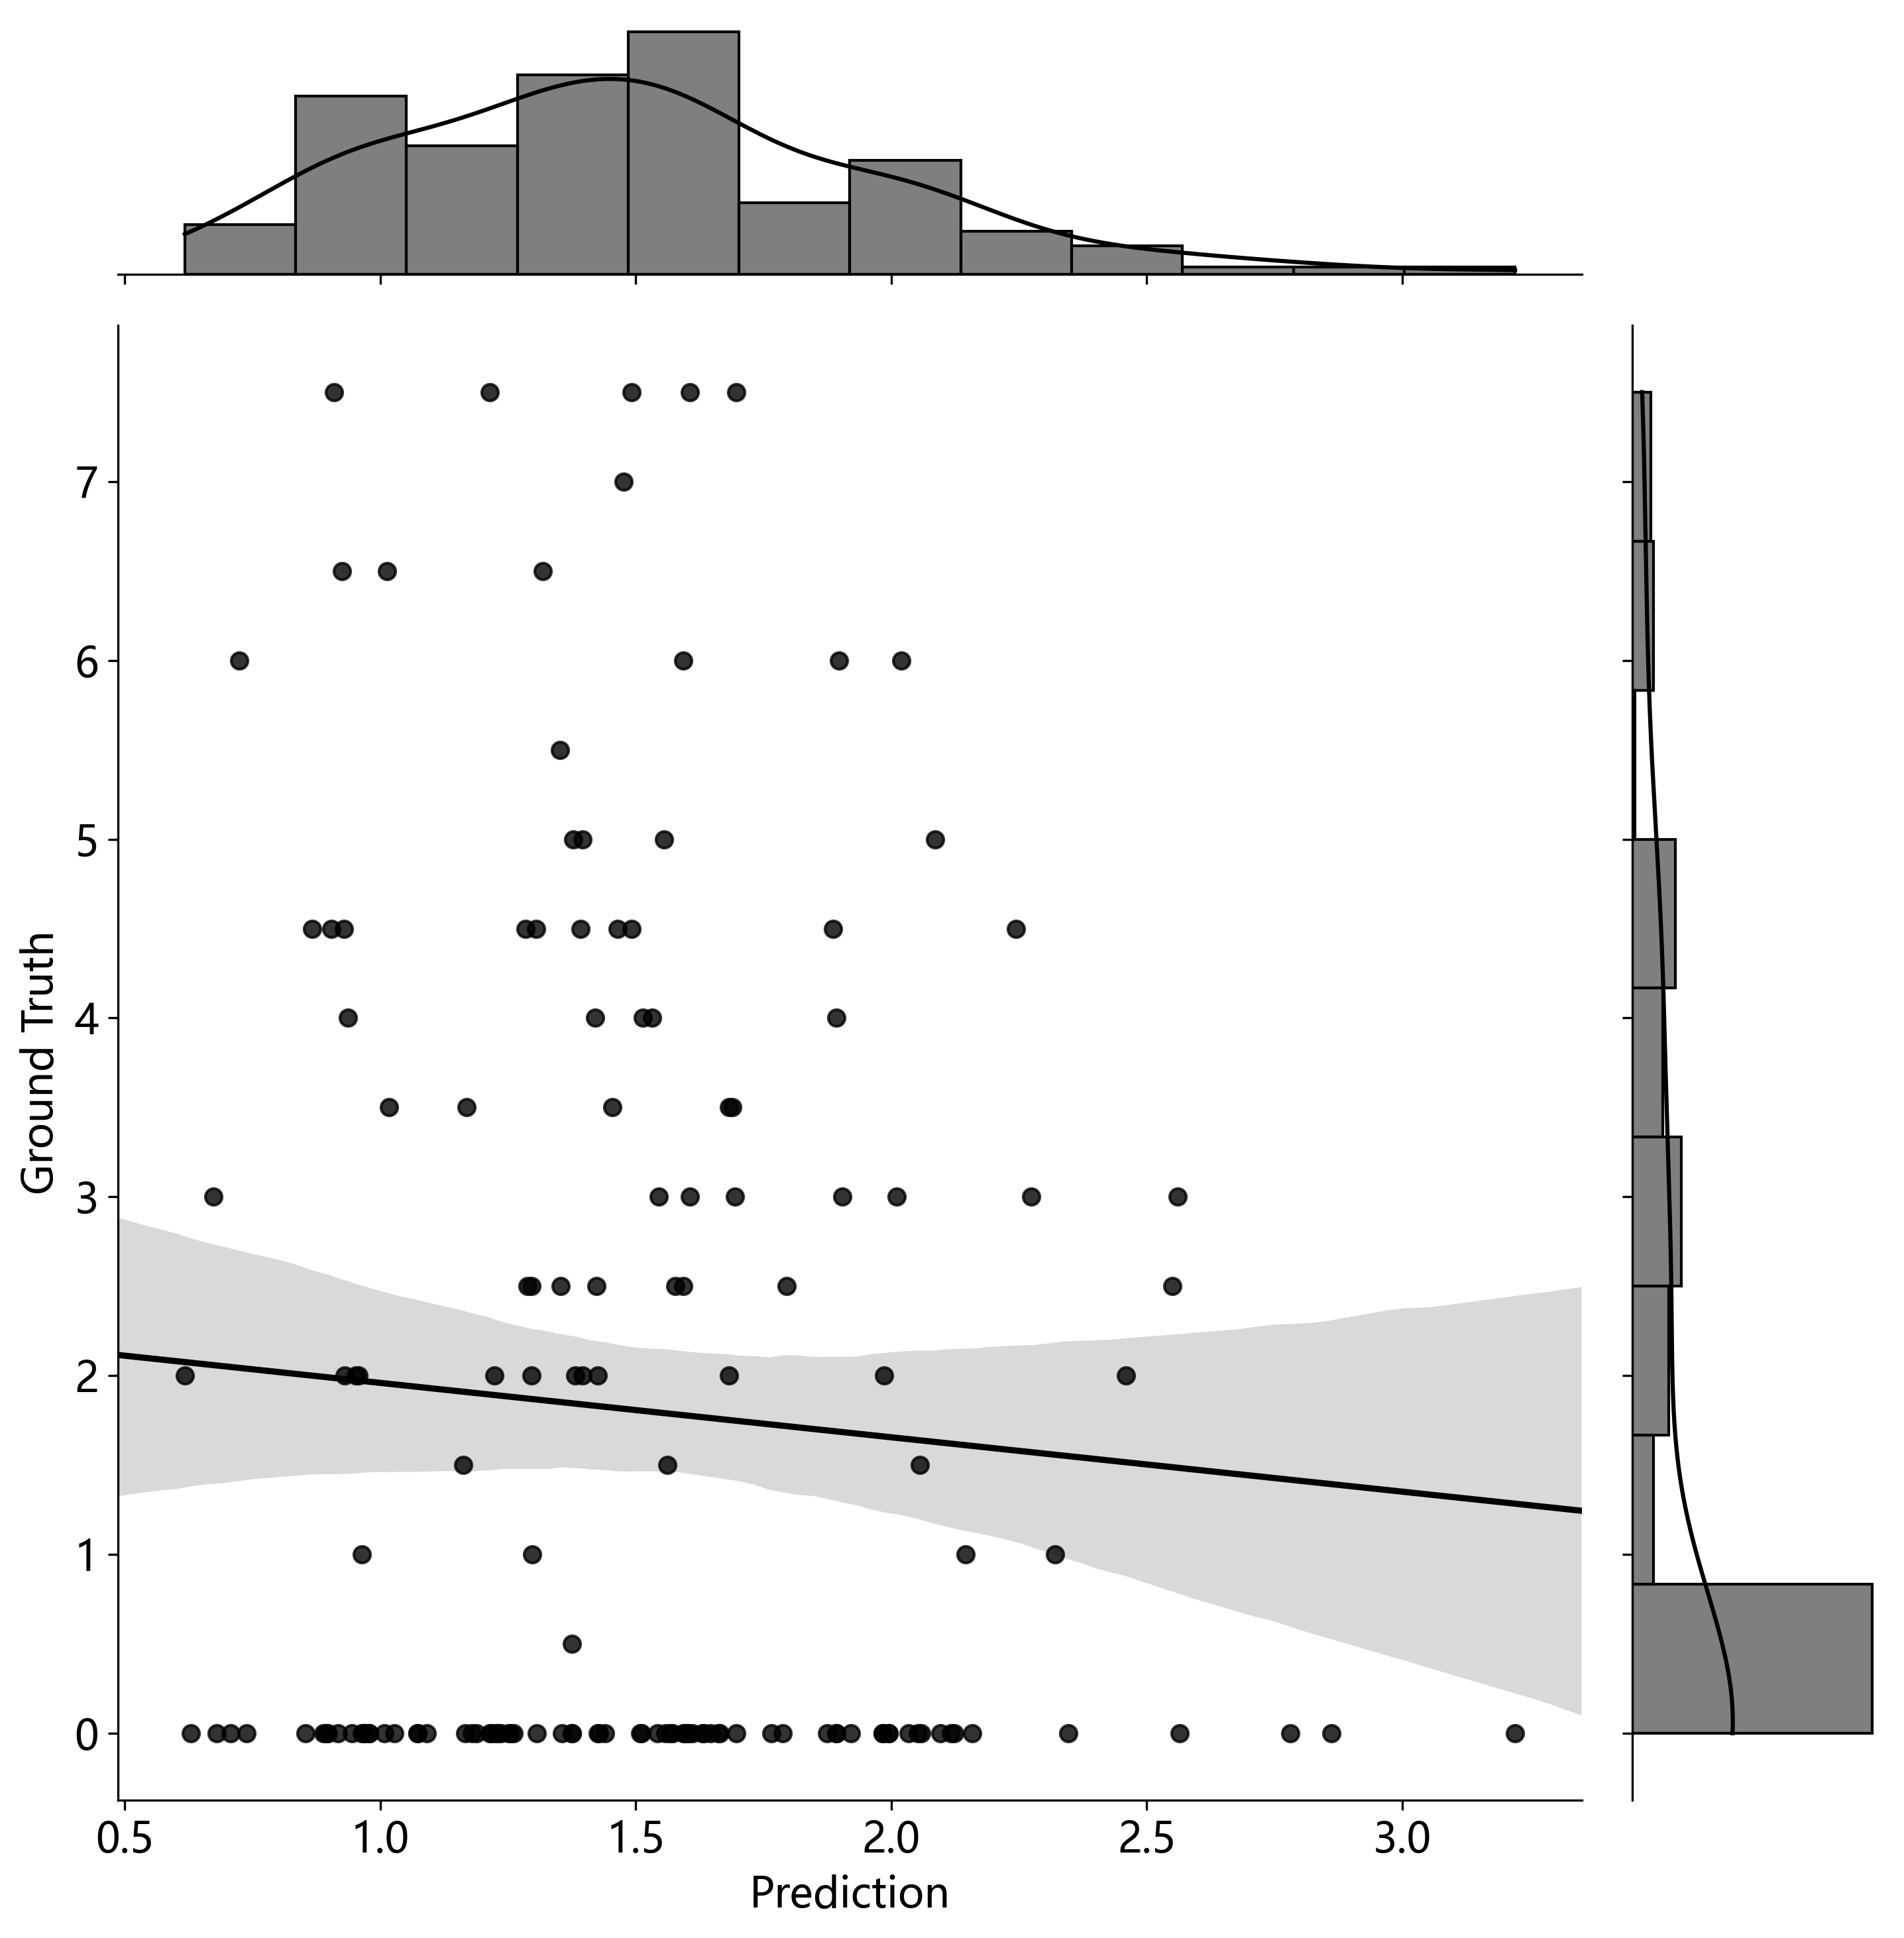

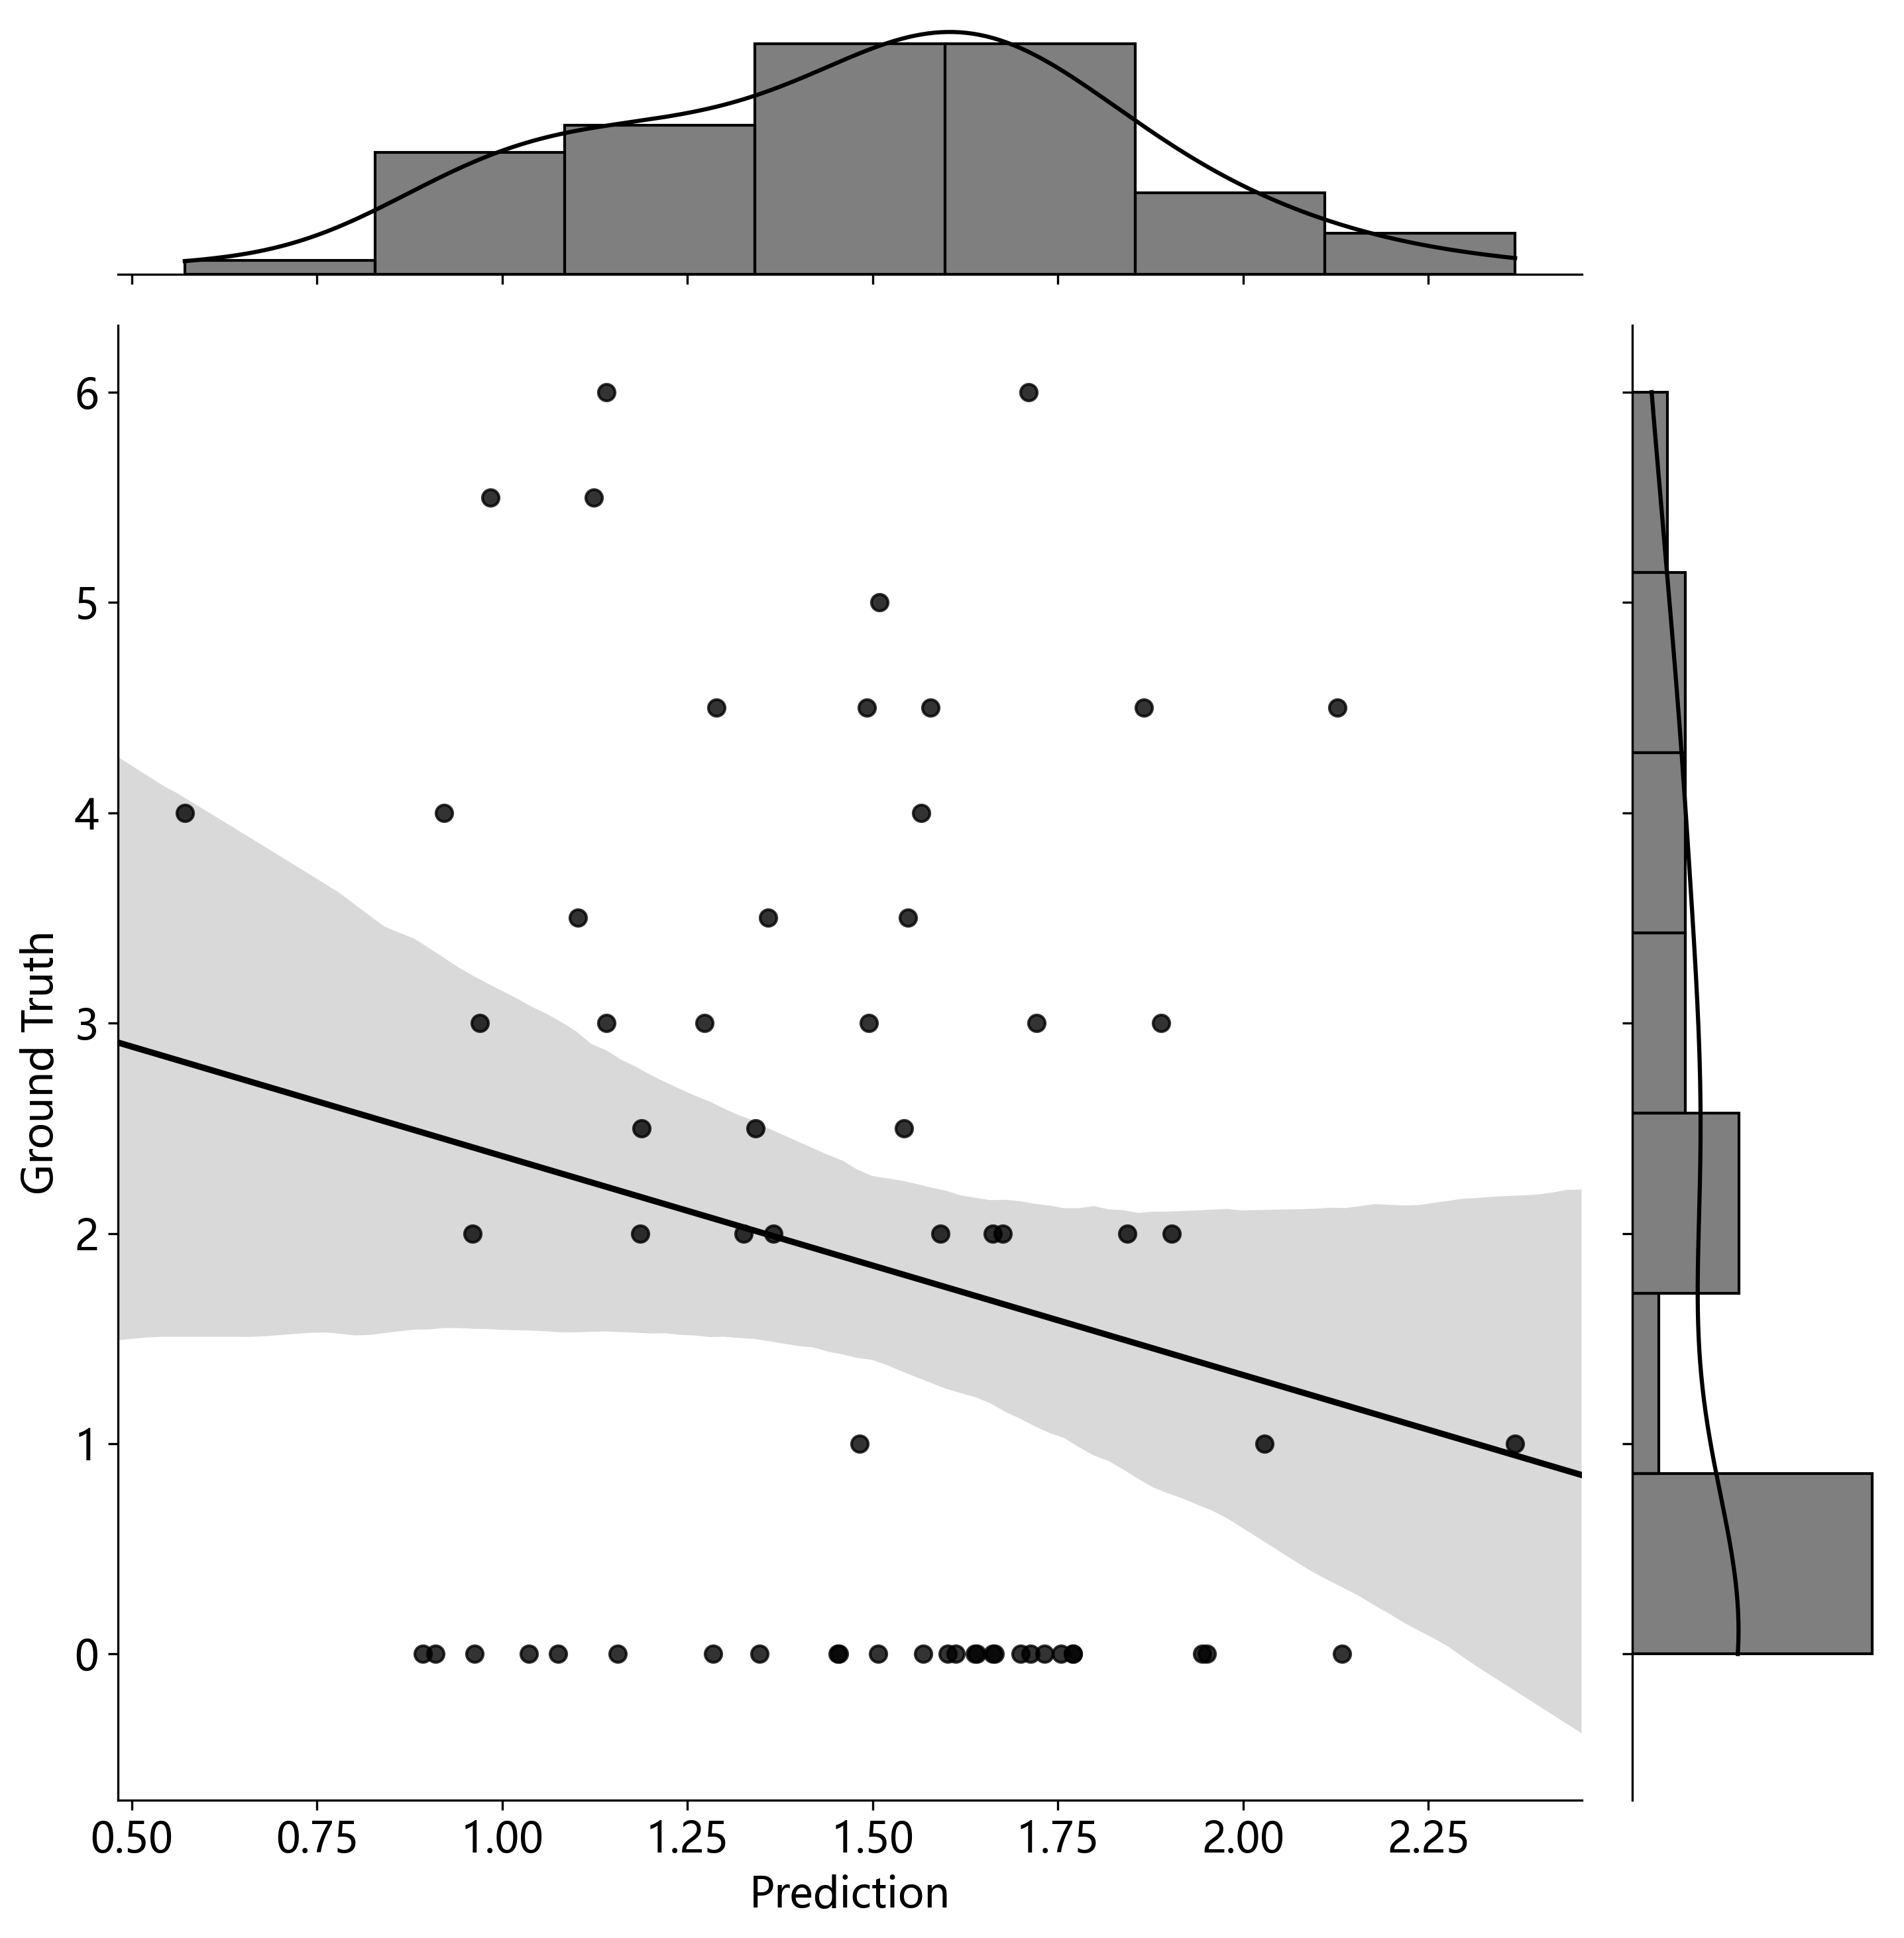

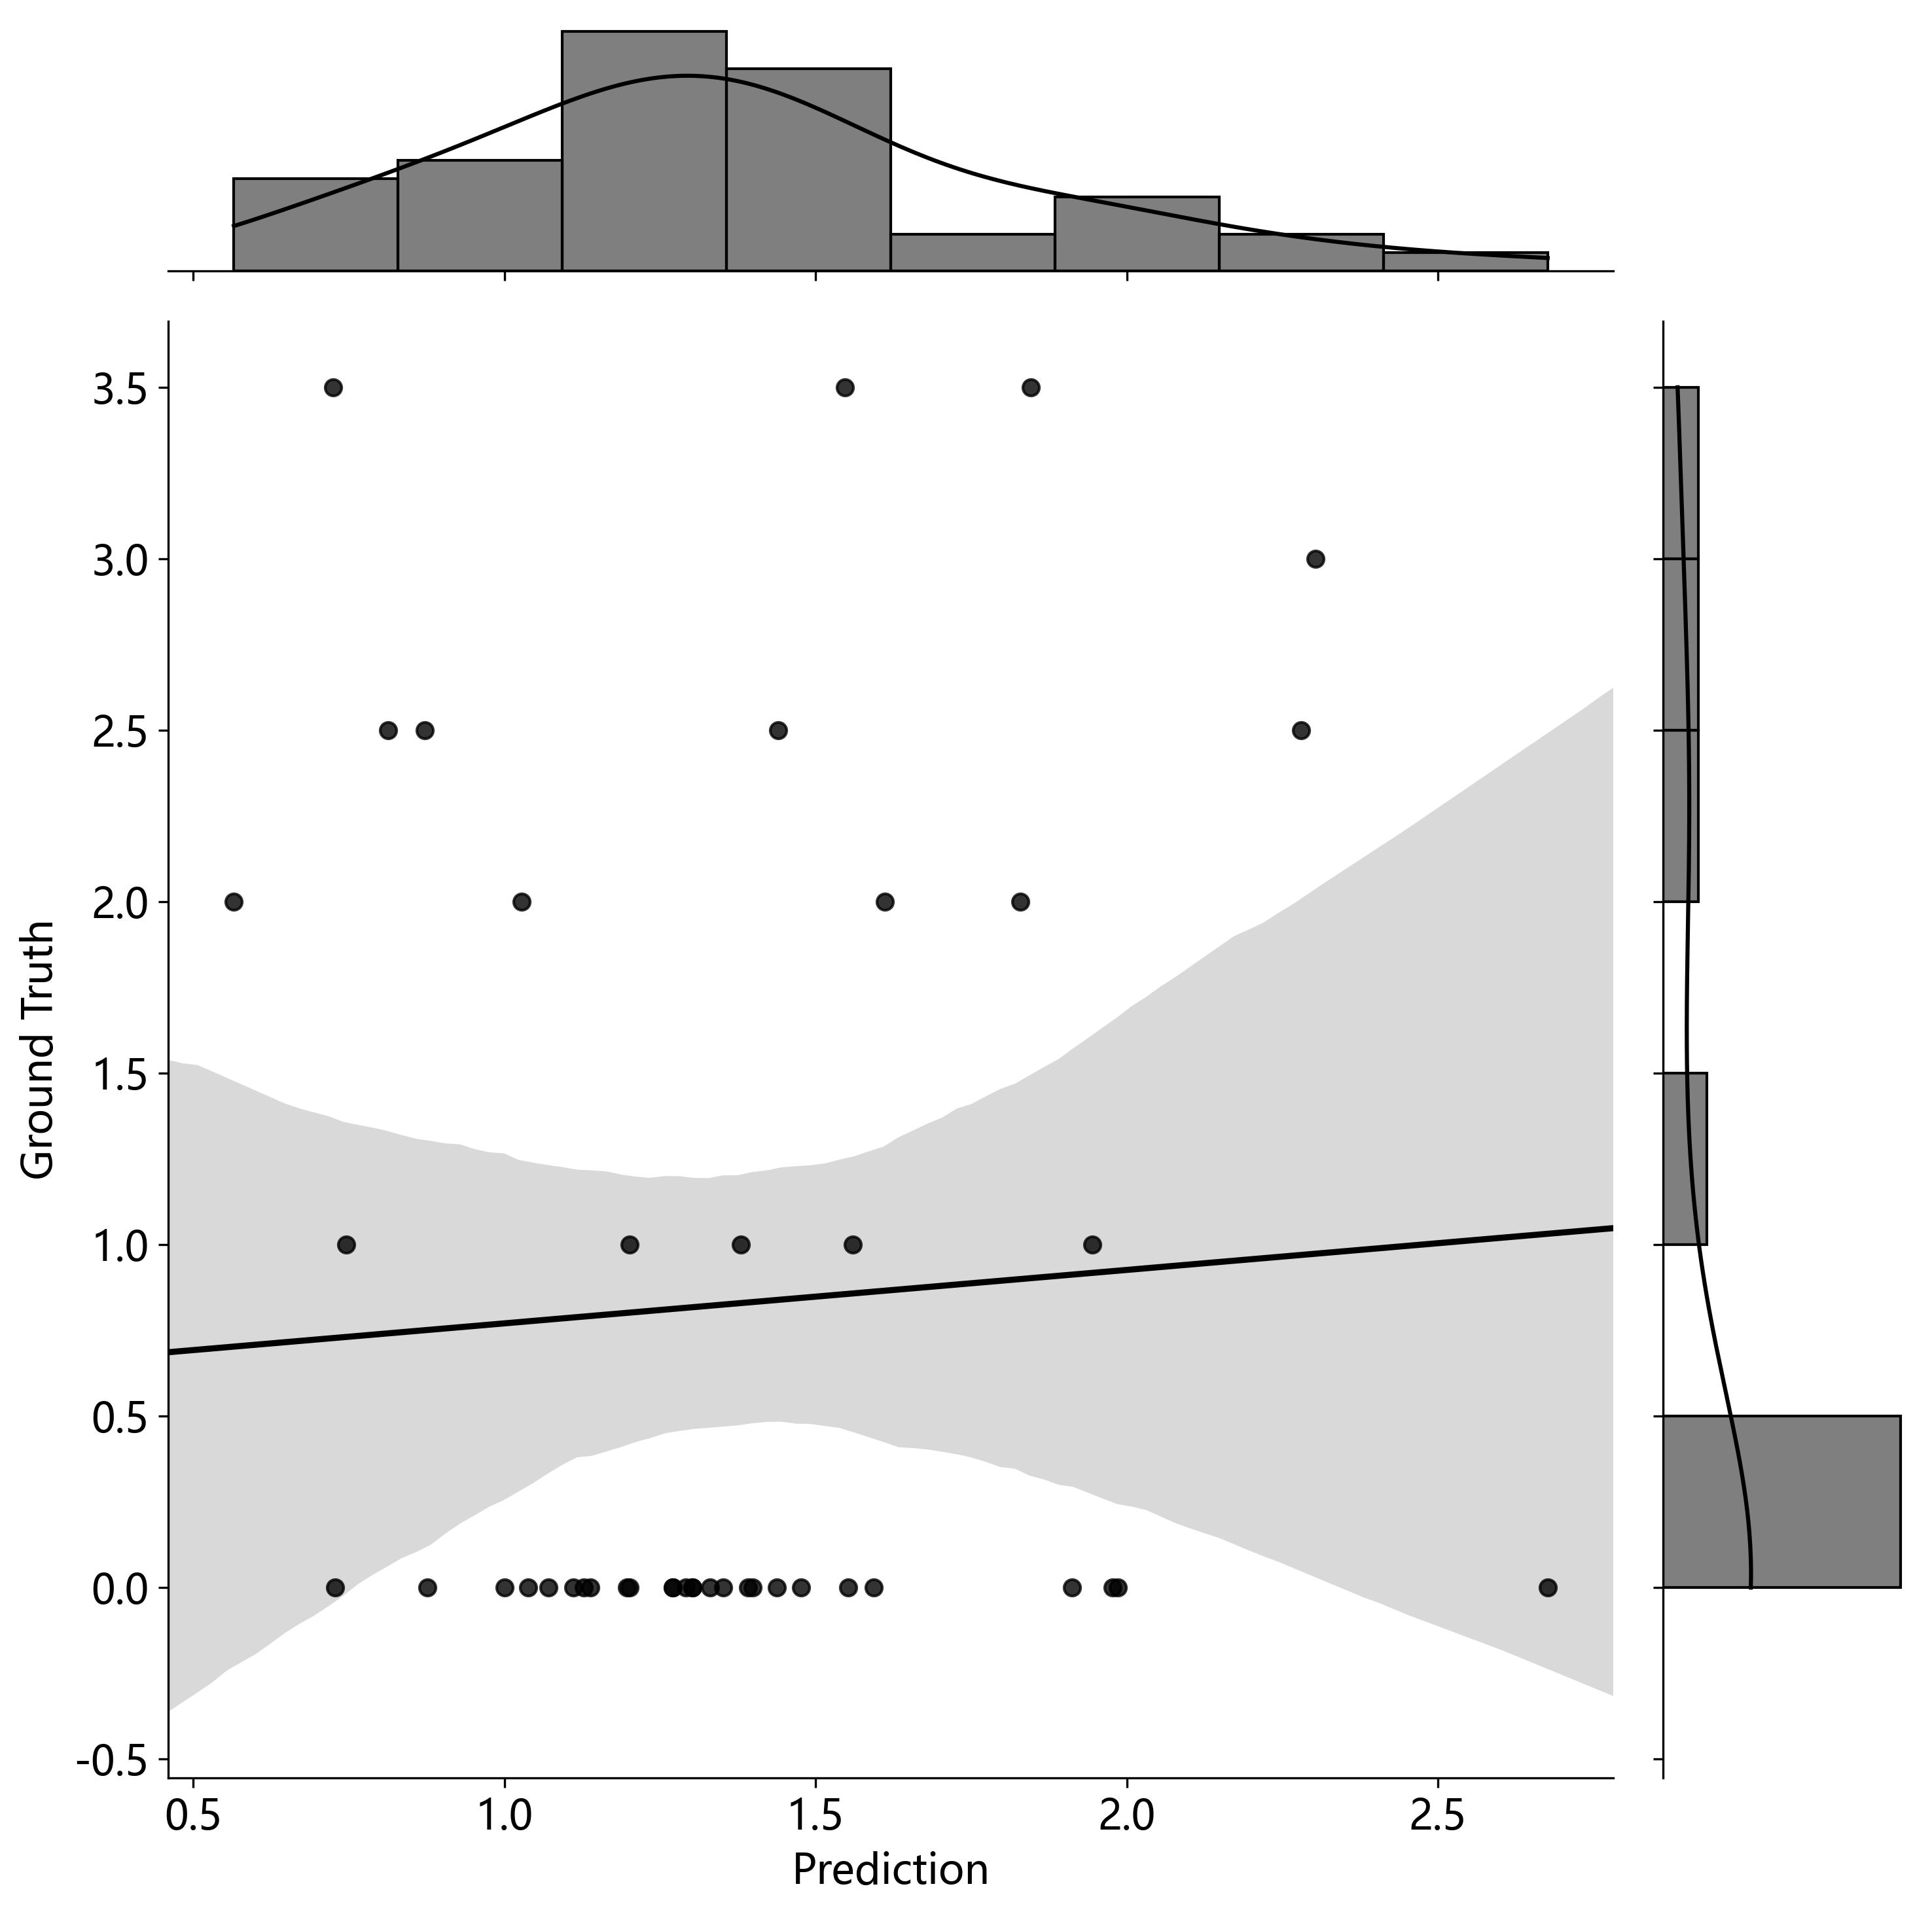

In [15]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def map2e(x):
    return math.exp(x) - 1


os.makedirs('img', exist_ok=True)
sns.set_palette(["black", "gray", "white"])

sel_model = 'densenet121'
for sel_model in models:
    log = pd.concat(logs, axis=0)
    log = log[log['model'] == sel_model]
    for subset in get_param_in_cwd('subsets'):
        val_log = log[log['group'] == subset].copy()
        for c in ['Prediction', 'Ground Truth']:
            val_log[c] = val_log[c].map(lambda x: map2e(x))
    #     display(val_log)
        val_log = remove_outliers_percentile(val_log, 'Ground Truth', lower_percentile=0, upper_percentile=90)
        sns.jointplot(y='Ground Truth', x=f'Prediction', data=val_log,  kind="reg", truncate=False, height=10)
        plt.savefig(f'img/{modal}_{sel_model}_{subset}_regression.svg', bbox_inches='tight')
        plt.show()